In [16]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
ecoli = pd.read_csv('../ncbi_562_data.csv')
salmonella = pd.read_csv('../ncbi_590_data.csv')


C:\Users\bryan\AppData\Local\Temp\ipykernel_9860\3435894081.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  salmonella = pd.read_csv('../ncbi_590_data.csv')


In [17]:
ecoli = ecoli[ecoli['is_usa_based'] == 1]
ecoli['collection_year'] = pd.to_numeric(ecoli['collection_year'], errors='coerce')
ecoli = ecoli[ecoli['collection_year'] >= 2009]
ecoli = ecoli[ecoli['month'].notna()]
ecoli['collection_year'] = ecoli['collection_year'].astype(str)
ecoli['collection_year'] = ecoli['collection_year'].str[:4]
ecoli['month'] = ecoli['month'].astype(int)
ecoli['month'] = ecoli['month'].apply(lambda x: f"{x:02d}")
ecoli['year_and_month'] = ecoli['collection_year'] + '-' + ecoli['month']

salmonella = salmonella[salmonella['is_usa_based'] == 1]
salmonella['collection_year'] = pd.to_numeric(salmonella['collection_year'], errors='coerce')
salmonella = salmonella[salmonella['collection_year'] >= 2009]
salmonella = salmonella[salmonella['month'].notna()]
salmonella['collection_year'] = salmonella['collection_year'].astype(str)
salmonella['collection_year'] = salmonella['collection_year'].str[:4]
salmonella['month'] = salmonella['month'].astype(int)
salmonella['month'] = salmonella['month'].apply(lambda x: f"{x:02d}")
salmonella['year_and_month'] = salmonella['collection_year'] + '-' + salmonella['month']

In [18]:
ecoli['setting'] = ecoli['isolation_source'].copy()
ecoli['setting'] = ecoli['setting'].replace(['.*water.*', '.*pond.*', '.*River.*'], 'Water', regex=True)
ecoli['setting'] = ecoli['setting'].replace(['.*farm.*', '.*Farm.*', '.*stable.*', '.*barn.*', '.* feces.*', '.*feces .*'], 'Farm', regex=True)
ecoli['setting'] = ecoli['setting'].replace(['.*Hospital.*', '.*city.*', '.*urban.*'], 'Community', regex=True)
# If isolation_source is "blood" and host is "Homo sapiens", replace setting with "Community"
ecoli.loc[(ecoli['isolation_source'].str.contains('blood', case=False, na=False)) & (ecoli['host'].str.contains('Homo sapiens', case=False, na=False)), 'setting'] = 'Community'
ecoli.loc[(ecoli['isolation_source'].str.contains('missing', case=False, na=False)) & (ecoli['host'].str.contains('cow', case=False, na=False)), 'setting'] = 'Farm'
ecoli.loc[(ecoli['isolation_source'].str.contains('missing', case=False, na=False)) & (ecoli['host'].str.contains('Homo sapiens', case=False, na=False)), 'setting'] = 'Community'
ecoli.loc[(ecoli['isolation_source'].str.contains('missing', case=False, na=False)) & (ecoli['host'].str.contains('missing', case=False, na=False)), 'setting'] = 'Other/Unknown'
ecoli.loc[(ecoli['isolation_source'].str.contains('urine', case=False, na=False)) & (ecoli['host'].str.contains('Homo sapiens', case=False, na=False)), 'setting'] = 'Community'
ecoli.loc[(ecoli['isolation_source'].str.contains('missing', case=False, na=False)) & (ecoli['geo_loc_name'].str.contains('Creek', case=False, na=False)), 'setting'] = 'Farm'
ecoli.loc[(ecoli['isolation_source'].str.contains('feces', case=False, na=False)) & (ecoli['source_type'].str.contains('animal', case=False, na=False)), 'setting'] = 'Farm'
ecoli.loc[ecoli['source_type'].str.contains('human', case=False, na=False), 'setting'] = 'Community'
ecoli.loc[ecoli['isolation_source'].str.contains('manure', case=False, na=False), 'setting'] = 'Farm'
ecoli.loc[ecoli['isolation_source'].str.contains('Ground beef', case=False, na=False), 'setting'] = 'Community'
ecoli.loc[ecoli['isolation_source'].str.contains('ground beef', case=False, na=False), 'setting'] = 'Community'
ecoli.loc[ecoli['setting'].str.contains(' fecal', case=False, na=False), 'setting'] = 'Farm'




In [19]:
salmonella['setting'] = salmonella['isolation_source'].copy()
salmonella['setting'] = salmonella['setting'].replace(['.*water.*', '.*pond.*', '.*River.*'], 'Water', regex=True)
salmonella['setting'] = salmonella['setting'].replace(['.*farm.*', '.*Farm.*', '.*stable.*', '.*barn.*', '.* feces.*', '.*feces .*'], 'Farm', regex=True)
salmonella['setting'] = salmonella['setting'].replace(['.*Hospital.*', '.*city.*', '.*urban.*'], 'Community', regex=True)
# If isolation_source is "blood" and host is "Homo sapiens", replace setting with "Community"
salmonella.loc[(salmonella['isolation_source'].str.contains('blood', case=False, na=False)) & (salmonella['host'].str.contains('Homo sapiens', case=False, na=False)), 'setting'] = 'Community'
salmonella.loc[(salmonella['isolation_source'].str.contains('missing', case=False, na=False)) & (salmonella['host'].str.contains('cow', case=False, na=False)), 'setting'] = 'Farm'
salmonella.loc[(salmonella['isolation_source'].str.contains('missing', case=False, na=False)) & (salmonella['host'].str.contains('Homo sapiens', case=False, na=False)), 'setting'] = 'Community'
salmonella.loc[(salmonella['isolation_source'].str.contains('missing', case=False, na=False)) & (salmonella['host'].str.contains('missing', case=False, na=False)), 'setting'] = 'Other/Unknown'
salmonella.loc[(salmonella['isolation_source'].str.contains('urine', case=False, na=False)) & (salmonella['host'].str.contains('Homo sapiens', case=False, na=False)), 'setting'] = 'Community'
salmonella.loc[(salmonella['isolation_source'].str.contains('missing', case=False, na=False)) & (salmonella['geo_loc_name'].str.contains('Creek', case=False, na=False)), 'setting'] = 'Farm'
salmonella.loc[(salmonella['isolation_source'].str.contains('feces', case=False, na=False)) & (salmonella['source_type'].str.contains('animal', case=False, na=False)), 'setting'] = 'Farm'
salmonella.loc[salmonella['source_type'].str.contains('human', case=False, na=False), 'setting'] = 'Community'
salmonella.loc[salmonella['isolation_source'].str.contains('manure', case=False, na=False), 'setting'] = 'Farm'
salmonella.loc[salmonella['isolation_source'].str.contains('Ground beef', case=False, na=False), 'setting'] = 'Community'
salmonella.loc[salmonella['isolation_source'].str.contains('ground beef', case=False, na=False), 'setting'] = 'Community'
salmonella.loc[salmonella['setting'].str.contains(' fecal', case=False, na=False), 'setting'] = 'Farm'

In [20]:
ecoli['setting'].value_counts()

setting
Community                                                                                                                    44046
Farm                                                                                                                          5007
ground turkey                                                                                                                 2122
urine                                                                                                                         1626
stool                                                                                                                         1047
Water                                                                                                                          882
chicken breast                                                                                                                 437
missing                                                                    

In [21]:
ecoli[ecoli['setting'] == 'bovine fecal'].head(20)

,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,submitter,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,new_host,collection_year,month,nors_primary_mode_map,year_and_month,setting


In [22]:
ecoli = ecoli[ecoli['setting'].isin(['Community', 'Farm', 'Water', 'Other/Unknown'])]
salmonella = salmonella[salmonella['setting'].isin(['Community', 'Farm', 'Water', 'Other/Unknown'])]


In [23]:
#ecoli group by setting and year_and_month
ecoli_three = ecoli.groupby(['year_and_month', 'setting']).size().unstack(fill_value=0)
salmonella_three = salmonella.groupby(['year_and_month', 'setting']).size().unstack(fill_value=0)


In [24]:
ecoli_three

setting,Community,Farm,Other/Unknown,Water
year_and_month,,,,
2009-01,7,0,0,0
2009-02,4,2,0,0
2009-03,2,0,0,0
2009-04,8,4,0,0
2009-05,8,0,0,0
2009-06,23,0,0,0
2009-07,18,0,0,0
2009-08,9,0,0,0
2009-09,26,0,0,0


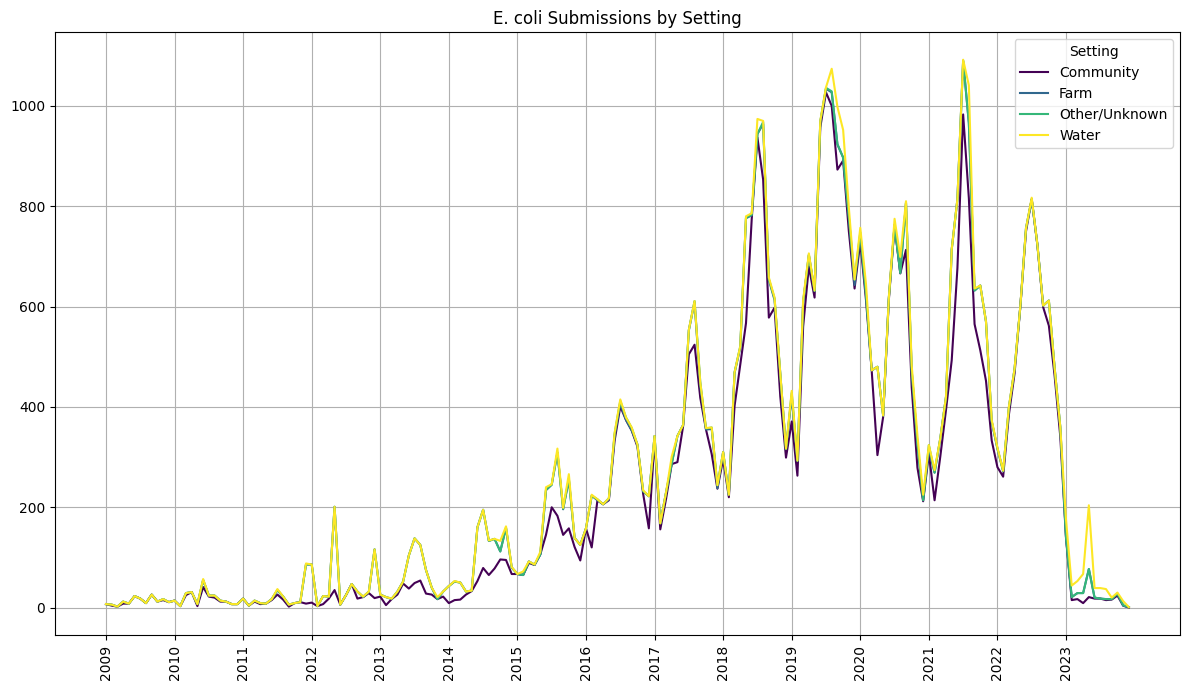

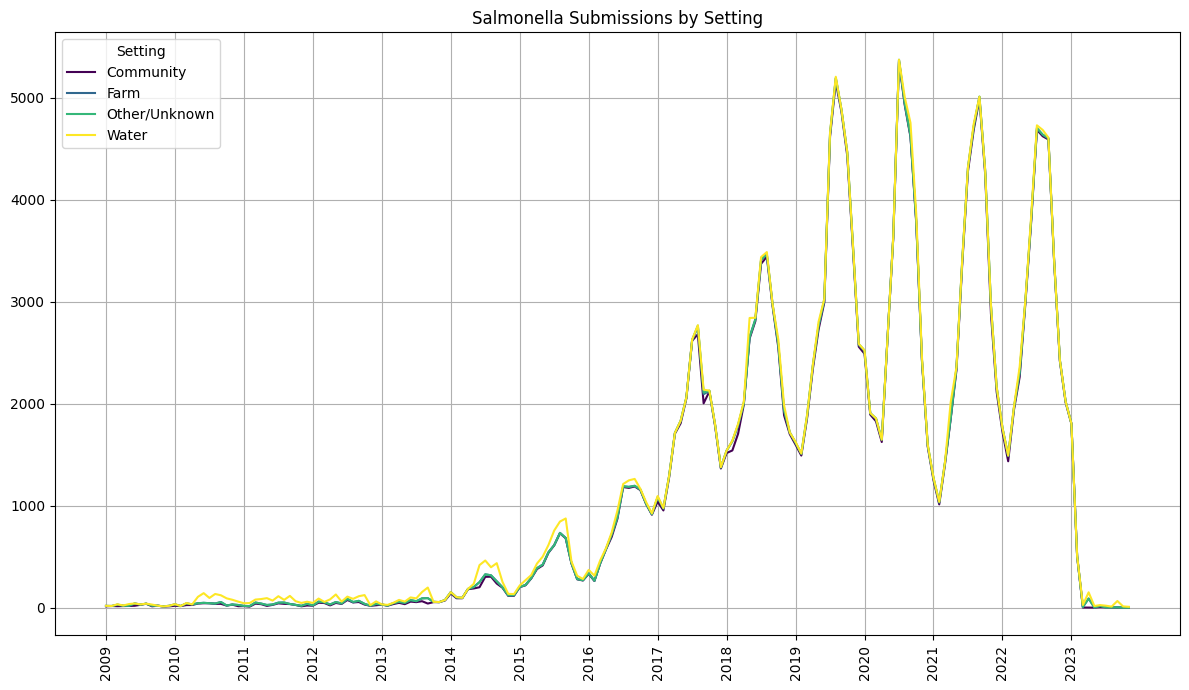

In [29]:
#bar plot of ecoli_three settings count use plt

ecoli_three.plot(kind='line', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('E. coli Submissions by Setting')
plt.xlabel('')
plt.ylabel('')
plt.grid(axis = 'both')
plt.xticks(ticks=range(0, len(ecoli_three.index), 12), labels=[date[:4] for date in ecoli_three.index[::12]], rotation=90)
plt.legend(title='Setting')
plt.tight_layout()
plt.savefig('../outputs/ecoli_submissions_by_setting.tiff', dpi=400)
plt.show()

salmonella_three.plot(kind='line', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Salmonella Submissions by Setting')
plt.xlabel('')
plt.ylabel('')
plt.grid(axis = 'both')
plt.xticks(ticks=range(0, len(ecoli_three.index), 12), labels=[date[:4] for date in ecoli_three.index[::12]], rotation=90)
plt.legend(title='Setting')
plt.tight_layout()
plt.savefig('../outputs/salmonella_submissions_by_setting.tiff', dpi=400)
plt.show()
